## Scraping - HW 9

***Use the magical scraping prompt from https://gist.github.com/jsoma/dd28675ab27c5d46b6261b93f1252307 to scrape the following websites:***


### 1. Scrape the apple varieties from https://www.applesfromny.com/varieties/

*Tip: You'll run into a problem immediately! But just paste the error into your AI buddy and they'll solve it for you.*

In [61]:
import requests
from bs4 import BeautifulSoup

url = "https://www.applesfromny.com/varieties/"

# Add headers to mimic a real browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/118.0.5993.90 Safari/537.36"
}

response = requests.get(url, headers=headers)
if response.status_code == 200:
    print("Page fetched successfully!")
else:
    print(f"Failed to fetch page, status code: {response.status_code}")

# Parse the page
soup = BeautifulSoup(response.text, "html.parser")


Page fetched successfully!


In [64]:
import pandas as pd

# Find all apple varieties
apple_divs = soup.find_all("div", class_="apple-variety")

# Prepare a list to store the data
apple_data = []

for div in apple_divs:
    # Name
    name = div.find("h2").get_text(strip=True)
    
    # Description
    description = div.find("p").get_text(strip=True)
    
    # Image URL
    img_tag = div.find("img")
    image_url = img_tag['src'] if img_tag else None
    
    # Detail page URL
    a_tag = div.find("a", href=True)
    detail_url = a_tag['href'] if a_tag else None
    
    # Sweet-tart rating
    scale_div = div.find("div", class_="scale-icon")
    rating = None
    if scale_div and 'class' in scale_div.attrs:
        for cls in scale_div['class']:
            # Look for class like "scale-7" where 7 is the number
            if cls.startswith("scale-") and cls.split("-")[1].isdigit():
                rating_num = cls.split("-")[1]
                rating = f"{rating_num} of 7 sweet"
                break
    
    # Add to list
    apple_data.append({
        "Name": name,
        "Description": description,
        "Image URL": image_url,
        "Detail URL": detail_url,
        "Sweet/Tart Rating": rating
    })

# Convert to DataFrame
df = pd.DataFrame(apple_data)

# Preview
df.head()


,Name,Description,Image URL,Detail URL,Sweet/Tart Rating
0,20 Ounce,This heirloom variety is famous not only for i...,https://www.applesfromny.com/wp-content/upload...,https://www.applesfromny.com/varieties/20-ounce/,7 of 7 sweet
1,Acey Mac,"Sweet, tart and juicy.",https://www.applesfromny.com/wp-content/upload...,https://www.applesfromny.com/varieties/acey-mac/,6 of 7 sweet
2,Autumn Crisp,Cross between a Golden Delicious and a Monroe ...,https://www.applesfromny.com/wp-content/upload...,https://www.applesfromny.com/varieties/autumn-...,4 of 7 sweet
3,Braeburn,"Sweet, tangy and juicy.",https://www.applesfromny.com/wp-content/upload...,https://www.applesfromny.com/varieties/braeburn/,6 of 7 sweet
4,Cameo,"A bright, red-striped apple with a creamy oran...",https://www.applesfromny.com/wp-content/upload...,https://www.applesfromny.com/varieties/cameo/,2 of 7 sweet


In [65]:
# Save to CSV
df.to_csv("apple_varieties.csv", index=False)
print("Data saved to apple_varieties.csv")


Data saved to apple_varieties.csv


### 2. Scrape the prison facility locations from https://doc.la.gov/about-the-dpsc/facility-locations/

*Tip: You'll want to start a new conversation for each one, it gets confused otherwise*

In [72]:
# Install necessary packages if you haven't already
# !pip install requests beautifulsoup4 pandas

import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL of the facilities page
url = "https://doc.la.gov/about-the-dpsc/facility-locations/"

# Fetch the page
response = requests.get(url)
response.raise_for_status()  # make sure the request succeeded

# Parse with BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# Preview the HTML to make sure it loaded correctly
print(soup.prettify()[:1000])  # show first 1000 characters


<!DOCTYPE html>
<html class="no-js" lang="en-US">
 <head>
  <!-- HTML Boilerplte v6.01 -->
  <meta charset="utf-8"/>
  <meta content="ie=edge" http-equiv="x-ua-compatible"/>
  <title>
   Facility Locations - Louisiana Department of Public Safety &amp; Corrections
  </title>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <meta content="_cgAvPhVHKTuzcUzfB7ipIjbT_kIiPoS3H-542lnBPg" name="google-site-verification">
   <link href="https://doc.la.gov/wp-content/themes/doc-louisiana/favicon.png" rel="shortcut icon" type="image/png"/>
   <!-- remove below link if google font is not used -->
   <link crossorigin="" href="https://fonts.gstatic.com" rel="preconnect"/>
   <link href="http://gmpg.org/xfn/11" rel="profile">
    <meta content="index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1" name="robots">
     <style>
      img:is([sizes="auto" i], [sizes^="auto," i]) { contain-intrinsic-size: 3000px 1500px }
     </style>
     <!-- This site i

In [75]:
# Find all facility items
facilities = soup.find_all("li", class_="location")

# Extract data
data = []
for facility in facilities:
    name = facility.find("div", class_="title-block").find("h3").get_text(strip=True)
    
    # Check if phone exists
    phone_block = facility.find("div", class_="phone-block")
    phone = phone_block.find("h3").get_text(strip=True) if phone_block else ""
    
    url = facility.find("a")["href"]
    
    data.append({
        "Facility Name": name,
        "Phone": phone,
        "URL": url
    })

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview first few rows
df.head()


,Facility Name,Phone,URL
0,Allen Correctional Center,(337) 639-2943,https://doc.la.gov/location/allen-correctional...
1,B.B. Rayburn Correctional Center,(985) 661-6300,https://doc.la.gov/location/b-b-rayburn-correc...
2,David Wade Correctional Center,(318) 927-0400,https://doc.la.gov/location/david-wade-correct...
3,Dixon Correctional Institute,(225) 634-1200,https://doc.la.gov/location/dixon-correctional...
4,Elayn Hunt Correctional Center,(225) 642-3306,https://doc.la.gov/location/elayn-hunt-correct...


In [76]:
# Save the DataFrame to a CSV file
df.to_csv("louisiana_facilities.csv", index=False)

print("CSV saved successfully! Number of facilities:", len(df))


CSV saved successfully! Number of facilities: 124


### 3. Scrape Arkansas State Police Commission meeting minutes from https://dps.arkansas.gov/law-enforcement/arkansas-state-police/directors-office/asp-commission/asp-commission-meeting-minutes/

*Tip: What should be a row? What should be a column?*

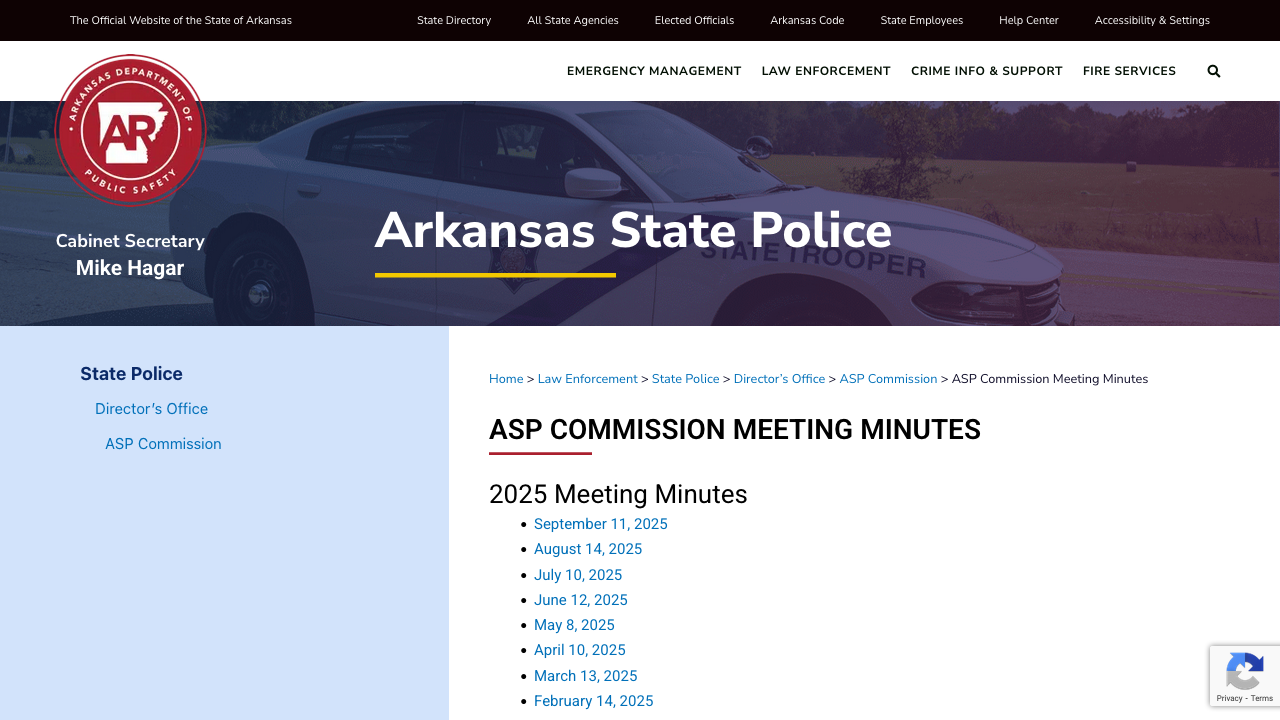

<!DOCTYPE html><html lang="en-US"><head><meta charset="UTF-8"><script type="text/javascript" async="" charset="utf-8" src="https://www.gstatic.com/recaptcha/releases/jdMmXeCQEkPbnFDy9T04NbgJ/recaptcha__en.js" crossorigin="anonymous" integrity="sha384-z6SN+4u+ZOsIgYWusRxHPQ9aBi4w1u4L9UfLCVIX0xSiSVpm3SfVdEuAXmzYtysM"></script><script>if(navigator.userAgent.match(/MSIE|Internet Explorer/i)||navigator.userAgent.match(/Trident\/7\..*?rv:11/i)){var href=document.location.href;if(!href.match(/[?&]nowprocket/)){if(href.indexOf("?")==-1){if(href.indexOf("#")==-1){document.location.href=href+"?nowprocket=1"}else{document.location.href=href.replace("#","?nowprocket=1#")}}else{if(href.indexOf("#")==-1){document.location.href=href+"&nowprocket=1"}else{document.location.href=href.replace("#","&nowprocket=1#")}}}}</script><script>(()=>{class RocketLazyLoadScripts{constructor(){this.v="2.0.4",this.userEvents=["keydown","keyup","mousedown","mouseup","mousemove","mouseover","mouseout","touchmove","touch

In [77]:
# Cell 3 (Jupyter-compatible): Fetch the page using Playwright (headful)
import asyncio
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
from IPython.display import Image, display

async def fetch_page():
    async with async_playwright() as p:
        # Launch Firefox in headful mode
        browser = await p.firefox.launch(headless=False)
        context = await browser.new_context()
        page = await context.new_page()
        
        # Go to the page and wait until network is idle
        await page.goto(
            "https://dps.arkansas.gov/law-enforcement/arkansas-state-police/directors-office/asp-commission/asp-commission-meeting-minutes/",
            wait_until="networkidle"
        )
        
        # Take a screenshot and display it inline
        screenshot = await page.screenshot()
        display(Image(screenshot))
        
        # Get page content
        html = await page.content()
        
        await browser.close()
        return html

# Jupyter-compatible way to run async code
html = await fetch_page()
soup = BeautifulSoup(html, "html.parser")

# Preview the first 1000 characters
print(html[:1000])


In [78]:
# Cell 4: Extract meeting minutes and split dates
import pandas as pd

# Find all list items containing meeting links
items = soup.find_all("li", class_="has-black-color")

data = []
for li in items:
    a_tag = li.find("a")
    if a_tag:
        full_date = a_tag.text.strip()  # e.g., "September 11, 2025"
        pdf_link = a_tag['href']
        
        # Split date into month, day, year
        try:
            month, day_year = full_date.split(" ", 1)
            day, year = day_year.replace(",", "").split(" ")
        except ValueError:
            month, day, year = "", "", ""  # fallback if parsing fails
        
        data.append({
            "Month": month,
            "Day": day,
            "Year": year,
            "PDF Link": pdf_link
        })

# Convert to DataFrame
df = pd.DataFrame(data)
df.head(10)  # preview first 10 rows


,Month,Day,Year,PDF Link
0,September,11,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
1,August,14,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
2,July,10,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
3,June,12,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
4,May,8,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
5,April,10,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
6,March,13,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
7,February,14,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
8,January,16,2025,https://dps.arkansas.gov/wp-content/uploads/AS...
9,December,12,2024,https://dps.arkansas.gov/wp-content/uploads/AS...


In [79]:
# Cell 5: Save DataFrame to CSV
csv_filename = "asp_commission_meeting_minutes.csv"
df.to_csv(csv_filename, index=False)
print(f"Data saved to {csv_filename}")


Data saved to asp_commission_meeting_minutes.csv


### 4. Scrape the first ten pages of https://nij.ojp.gov/funding/awards/list

*Tip: Notice there's pagination on this one!*
*Tip: This one will most likely break partway through but you can recover from it*

In [80]:
# Cell 1: imports
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm.notebook import tqdm


In [81]:
# Cell 2 (headless, no screenshot)
import asyncio
from playwright.async_api import async_playwright

async def fetch_page_html_headless(page_number):
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)  # headless mode
        page = await browser.new_page()
        url = f"https://nij.ojp.gov/funding/awards/list?page={page_number}"
        await page.goto(url, wait_until="networkidle")
        
        html = await page.content()
        await browser.close()
        return html


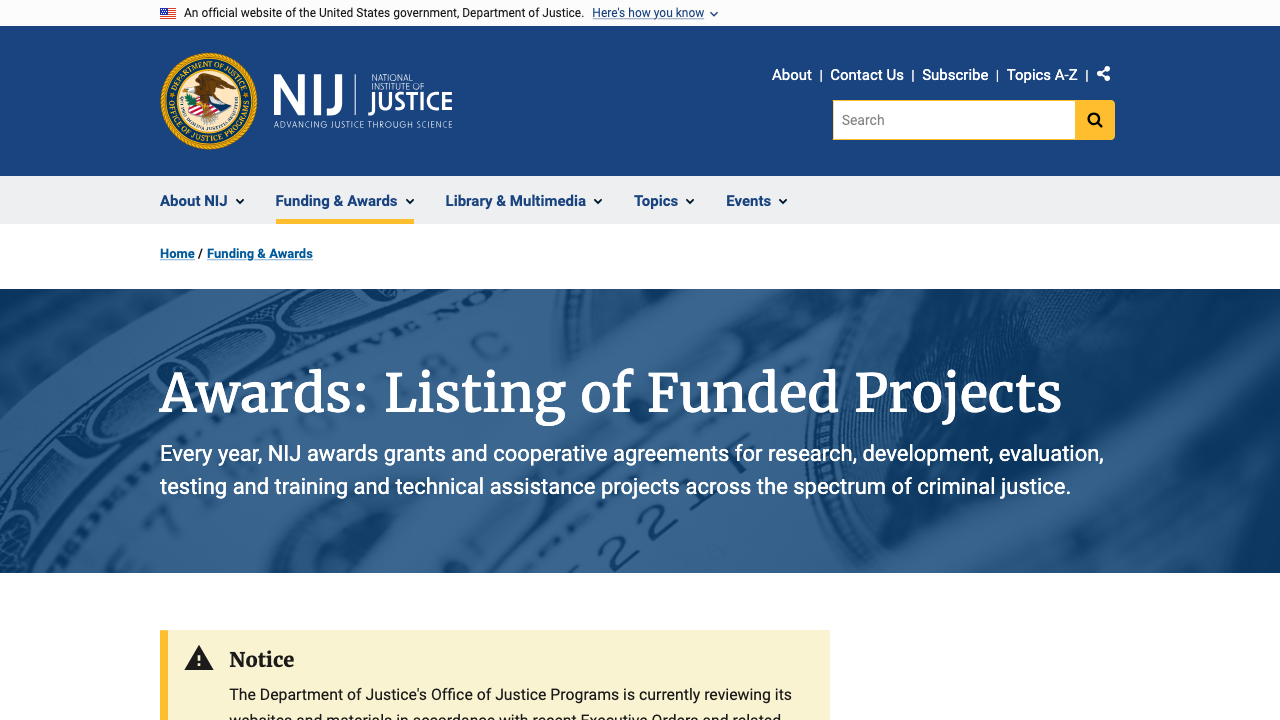

<!DOCTYPE html><html lang="en" dir="ltr" prefix="og: https://ogp.me/ns#" class=" js"><head>
    <meta charset="utf-8">
<link rel="preload" href="/themes/custom/ojp/assets/fonts/roboto/Roboto-Regular.woff2" as="font" type="font/woff2" crossorigin="">
<link rel="preload" href="/themes/custom/ojp/assets/fonts/roboto/Roboto-Bold.woff2" as="font" type="font/woff2" crossorigin="">
<link rel="preload" href="/themes/custom/ojp/assets/fonts/roboto/Roboto-Italic.woff2" as="font" type="font/woff2" crossorigin="">
<link rel="preload" href="/themes/custom/ojp/assets/fonts/roboto/Roboto-BlackItalic.woff2" as="font" type="font/woff2" crossorigin="">
<link rel="preload" href="/themes/custom/ojp/assets/fonts/merriweather/Latin-Merriweather-Regular.woff2" as="font" type="font/woff2" crossorigin="">
<link rel="preload" href="/themes/custom/ojp/assets/fonts/merriweather/Latin-Merriweather-Bold.woff2" as="font" type="font/woff2" crossorigin="">
<noscript><style>form.antibot * :not(.antibot-message) { displ

In [83]:
# If nest_asyncio isn't installed, install it first
# !pip install nest_asyncio
import nest_asyncio
nest_asyncio.apply()

# Now we can run async functions in Jupyter
import asyncio

page_0_html = asyncio.get_event_loop().run_until_complete(fetch_page_html(0))

# Print first 1000 characters to confirm
print(page_0_html[:1000])


In [84]:
def parse_awards_html(html):
    soup = BeautifulSoup(html, 'html.parser')
    awards_rows = soup.select('table.views-table tbody tr')
    
    awards_data = []
    for row in awards_rows:
        fiscal_year = row.select_one('td[headers="view-field-fiscal-year-table-column"]').get_text(strip=True)
        
        title_elem = row.select_one('td[headers="view-title-table-column"] a')
        title = title_elem.get_text(strip=True) if title_elem else ""
        title_link = "https://nij.ojp.gov" + title_elem['href'] if title_elem else ""
        
        funding_elem = row.select_one('td[headers="view-field-funding-opportunity-table-column"] a')
        funding_opportunity = funding_elem.get_text(strip=True) if funding_elem else ""
        funding_link = "https://nij.ojp.gov" + funding_elem['href'] if funding_elem else ""
        
        awardee_elem = row.select_one('td[headers="view-field-awardee-table-column"]')
        awardee = awardee_elem.get_text(strip=True) if awardee_elem else ""
        
        state_elem = row.select_one('td[headers="view-field-awardee-address-administrative-area-table-column"]')
        state = state_elem.get_text(strip=True) if state_elem else ""
        
        award_number_elem = row.select_one('td[headers="view-field-award-number-table-column"]')
        award_number = award_number_elem.get_text(strip=True) if award_number_elem else ""
        
        award_amount_elem = row.select_one('td[headers="view-field-award-amount-table-column"]')
        award_amount = award_amount_elem.get_text(strip=True) if award_amount_elem else ""
        
        award_status_elem = row.select_one('td[headers="view-field-award-status-table-column"]')
        award_status = award_status_elem.get_text(strip=True) if award_status_elem else ""
        
        awards_data.append({
            "Fiscal Year": fiscal_year,
            "Title": title,
            "Title Link": title_link,
            "Funding Opportunity": funding_opportunity,
            "Funding Link": funding_link,
            "Awardee": awardee,
            "State": state,
            "Award Number": award_number,
            "Award Amount": award_amount,
            "Award Status": award_status
        })
        
    return awards_data


In [85]:
# Cell 4 (headless scraping, first 10 pages)
all_awards = []

for page_number in tqdm(range(10), desc="Scraping pages"):
    print(f"Fetching page {page_number}...")
    html = asyncio.get_event_loop().run_until_complete(fetch_page_html_headless(page_number))
    awards = parse_awards_html(html)
    print(f"Found {len(awards)} awards on page {page_number}")
    all_awards.extend(awards)

# Convert to DataFrame
df_awards = pd.DataFrame(all_awards)
print(f"Total awards collected: {len(df_awards)}")
df_awards.head()


Scraping pages:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching page 0...
Found 25 awards on page 0
Fetching page 1...
Found 25 awards on page 1
Fetching page 2...
Found 25 awards on page 2
Fetching page 3...
Found 25 awards on page 3
Fetching page 4...
Found 25 awards on page 4
Fetching page 5...
Found 25 awards on page 5
Fetching page 6...
Found 25 awards on page 6
Fetching page 7...
Found 25 awards on page 7
Fetching page 8...
Found 25 awards on page 8
Fetching page 9...


Future exception was never retrieved
future: <Future finished exception=TargetClosedError('Target page, context or browser has been closed')>
playwright._impl._errors.TargetClosedError: Target page, context or browser has been closed


Found 25 awards on page 9
Total awards collected: 250


,Fiscal Year,Title,Title Link,Funding Opportunity,Funding Link,Awardee,State,Award Number,Award Amount,Award Status
0,2024,A Combined Molecular Analysis of Pollen Utiliz...,https://nij.ojp.gov/funding/awards/15pnij-24-g...,NIJ FY24 Graduate Research Fellowship,https://nij.ojp.gov/funding/opportunities/o-ni...,THE UNIVERSITY OF CENTRAL FLORIDA BOARD OF TRU...,FL,15PNIJ-24-GG-01571-RESS,"$120,000",Open
1,2024,A Comparative Evaluation of the MinION and MiS...,https://nij.ojp.gov/funding/awards/15pnij-24-g...,NIJ FY24 Research and Development in Forensic ...,https://nij.ojp.gov/funding/opportunities/o-ni...,FLORIDA INTERNATIONAL UNIVERSITY,FL,15PNIJ-24-GG-03842-SLFO,"$487,790",Open
2,2024,A Comprehensive Evaluation and Error Rate Asse...,https://nij.ojp.gov/funding/awards/15pnij-24-g...,NIJ FY24 Research and Development in Forensic ...,https://nij.ojp.gov/funding/opportunities/o-ni...,RESEARCH TRIANGLE INSTITUTE,NC,15PNIJ-24-GG-03851-SLFO,"$499,902",Open
3,2024,A Focused Deterrence Program for Juveniles wit...,https://nij.ojp.gov/funding/awards/15pnij-24-g...,NIJ FY24 Research and Evaluation on Youth Just...,https://nij.ojp.gov/funding/opportunities/o-ni...,FLORIDA STATE UNIVERSITY,FL,15PNIJ-24-GG-03092-MUMU,"$1,255,241",Open
4,2024,A Multi-District Analysis of School Safety in ...,https://nij.ojp.gov/funding/awards/15pnij-24-g...,NIJ FY24 Research and Evaluation on School Safety,https://nij.ojp.gov/funding/opportunities/o-ni...,RESEARCH TRIANGLE INSTITUTE,NC,15PNIJ-24-GK-01051-STOP,"$933,524",Open


In [86]:
# Cell 5: Save DataFrame to CSV
output_file = "nij_awards_first_10_pages.csv"
df_awards.to_csv(output_file, index=False)
print(f"Saved {len(df_awards)} awards to {output_file}")


Saved 250 awards to nij_awards_first_10_pages.csv
